In [1]:
"""
================================================================================
Machine Learning Pipeline: Retail Demand Forecasting
================================================================================

Script Purpose:
  This script executes an end-to-end machine learning pipeline to predict
  daily unit sales for specific items across multiple retail locations.
  Run this script to clean historical data, engineer features, train a 
  Random Forest model, and evaluate its predictive accuracy.
================================================================================
  
Specifications of the Forecasting Model:

Definition: 
    Predictive Demand Model (Regression)

Objective:
    Forecast future product demand to optimize inventory, minimize spoilage, 
    and maximize revenue for local food and retail businesses.

Data Inputs:
    Raw historical transaction data (Sales volume, base prices, promotions, dates)

Data Transformation: 
    - Date Parsing (Extracting Day, Month, Year for seasonal trends)
    - Categorical Encoding (One-Hot Encoding for Store IDs and Item SKUs)
    - Outlier Handling (Filtering top 1% extreme sales anomalies)

Machine Learning Modeling:
    - Algorithm: Random Forest Regressor
    - Hyperparameter Tuning: GridSearchCV 
    - Validation: 80/20 Train-Test Split

Evaluation Metrics:
    - RMSE (Root Mean Squared Error): Strictly penalizes large over/under-ordering mistakes
    - R-Squared (R²): Measures overall variance explained by the model

Target Audience:
    - Supply Chain Managers
    - Inventory Planners
    - Business Stakeholders
    
"""

'\n================================================================================\nMachine Learning Pipeline: Retail Demand Forecasting\n================================================================================\n\nScript Purpose:\n  This script executes an end-to-end machine learning pipeline to predict\n  daily unit sales for specific items across multiple retail locations.\n  Run this script to clean historical data, engineer features, train a \n  Random Forest model, and evaluate its predictive accuracy.\n================================================================================\n\nSpecifications of the Forecasting Model:\n\nDefinition: \n    Predictive Demand Model (Regression)\n\nObjective:\n    Forecast future product demand to optimize inventory, minimize spoilage, \n    and maximize revenue for local food and retail businesses.\n\nData Inputs:\n    Raw historical transaction data (Sales volume, base prices, promotions, dates)\n\nData Transformation: \n    - Date 

In [2]:
# IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import root_mean_squared_error

In [3]:
# DATA LOADING

df = pd.read_csv(r"C:\Users\Ben Ten\OneDrive\Desktop\Data With Baraa\Python\Demand Forecasting Project\train.csv.csv")
df.head()

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52


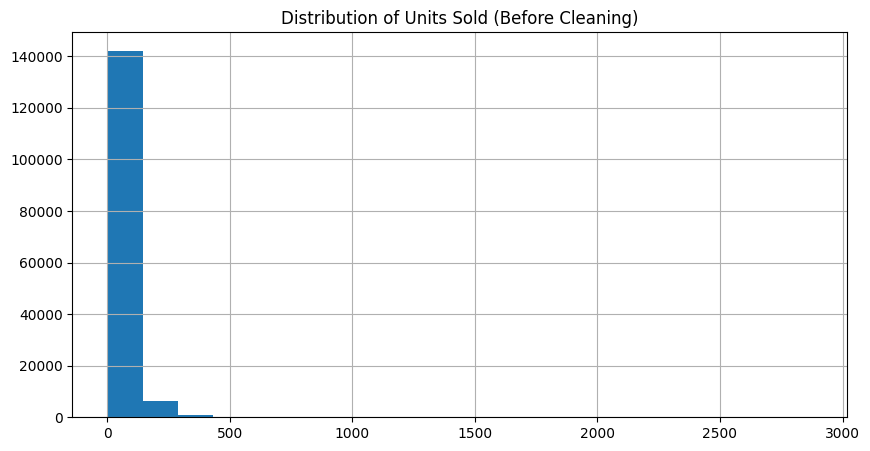

In [4]:
# PREPROCESSING & OUTLIER HANDLING

# Drop 'record_ID' as it's not a predictive feature
df = df.drop('record_ID', axis=1)

# Visualize the initial distribution of 'units_sold' to identify outliers
df.units_sold.hist(bins=20, figsize=(10, 5))
plt.title("Distribution of Units Sold (Before Cleaning)")
plt.show()

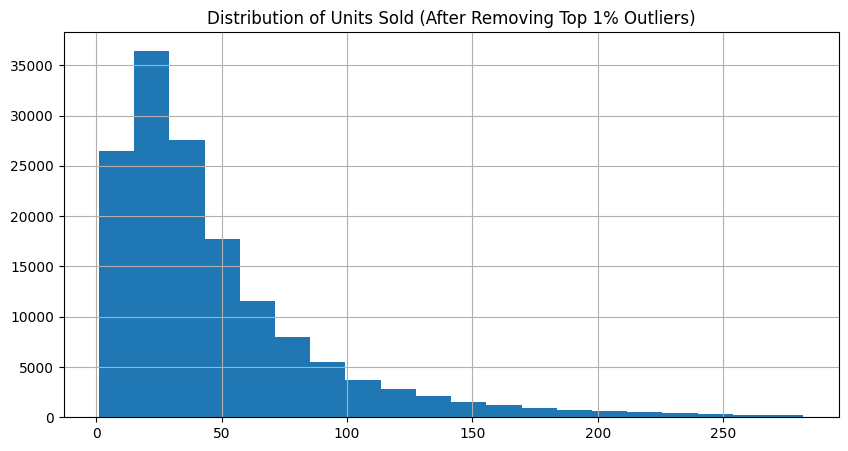

In [5]:
# Filtering out the top 1% of sales days to remove extreme outliers
df = df[df.units_sold < df.units_sold.quantile(0.99)]

# Visualize the distribution after outlier removal
df.units_sold.hist(bins=20, figsize=(10, 5))
plt.title("Distribution of Units Sold (After Removing Top 1% Outliers)")
plt.show()

In [6]:
# FEATURE ENGINEERING

# Expanding the Week Column to Extract Day, Month, Year inorder to detect trends, monthly buying patterns, and seasonality in demand
df[['day', 'month', 'year']] = df['week'].str.split('/', expand=True)
df = df.drop('week', axis=1)

In [7]:
# Categorical Encoding for Store IDs and Item SKUs (One-Hot Encoding)
# This prevents the model from incorrectly assuming Store #8023 is "greater than" Store #8022
df = df.join(pd.get_dummies(df.store_id, prefix='store')).drop('store_id', axis=1)
df = df.join(pd.get_dummies(df.sku_id, prefix='item')).drop('sku_id', axis=1)

df.head()

,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,store_8023,store_8058,...,item_320485,item_327492,item_378934,item_398721,item_545621,item_546789,item_547934,item_600934,item_673209,item_679023
0,99.0375,111.8625,0,0,20,17,01,11,False,False,...,False,False,False,False,False,False,False,False,False,False
1,99.0375,99.0375,0,0,28,17,01,11,False,False,...,False,False,False,False,False,False,False,False,False,False
2,133.9500,133.9500,0,0,19,17,01,11,False,False,...,False,False,False,False,False,False,False,False,False,False
3,133.9500,133.9500,0,0,44,17,01,11,False,False,...,False,False,False,False,False,False,False,False,False,False
4,141.0750,141.0750,0,0,52,17,01,11,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
# TRAIN TEST SPLIT

# Define features (X) by dropping the target column, and set the target (y)
x = df.drop('units_sold', axis=1)
y = df['units_sold']

# Split the data: 80% for training the model, 20% for testing its accuracy
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
# MODEL TRAINING & EVALUATION

# Initialize and train the Random Forest algorithm
model = RandomForestRegressor(n_jobs=-1)
model.fit(x_train, y_train)

# Calculate the R-squared score on the test set to evaluate how well the model explains variance in demand
r2_score = model.score(x_test, y_test)
print(f"Baseline R^2 Score: {r2_score:.4f}")

Baseline R^2 Score: 0.8254


In [10]:
# Generate predictions and calculate the Root Mean Squared Error (RMSE)
y_pred = model.predict(x_test)
rmse = root_mean_squared_error(y_pred, y_test)
print(f"Baseline RMSE: {rmse:.4f} units")

Baseline RMSE: 17.8378 units


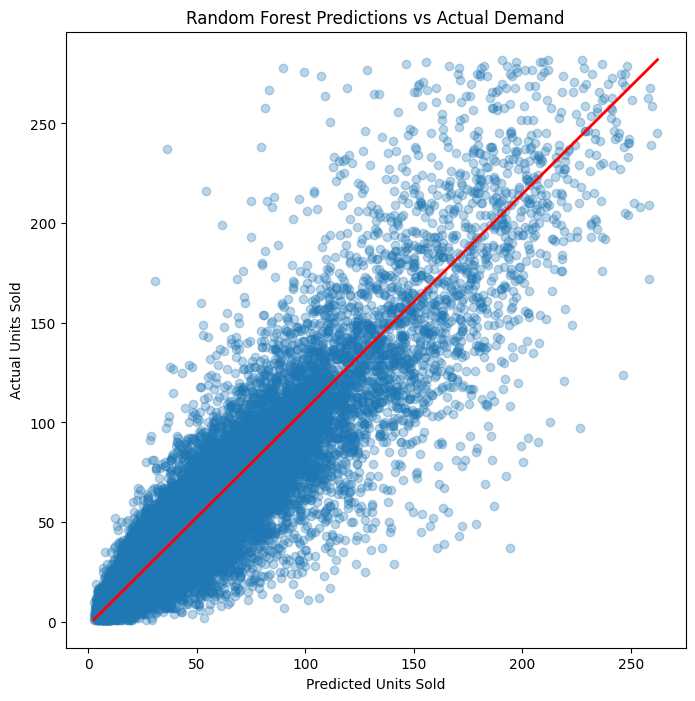

In [11]:
# Visualize the Model's Accuracy (Actual vs. Predicted)
# A perfect model would have all blue dots sitting exactly on the red diagonal line
plt.figure(figsize=(8, 8))
plt.scatter(y_pred, y_test, alpha=0.3)
plt.plot(np.linspace(y_pred.min(), y_pred.max()), 
         np.linspace(y_test.min(), y_test.max()), 
         color="red", linewidth=2)
plt.xlabel("Predicted Units Sold")
plt.ylabel("Actual Units Sold")
plt.title("Random Forest Predictions vs Actual Demand")
plt.show()

In [12]:
# HYPERPARAMETER TUNING - GRID SEARCH (For maximum accuracy)

# Defining the grid
param_grid = {
    'n_estimators': [10, 20],          # Number of trees in the forest
    'min_samples_split': [2, 3]        # Minimum data points required to split a tree node
}

# Initialize and Run GridSearchCV to test all combinations using Cross-Validation (cv=3)
grid_search = GridSearchCV(RandomForestRegressor(n_jobs=-1), param_grid, verbose=2, cv=3)
grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ...............min_samples_split=2, n_estimators=10; total time=   4.2s
[CV] END ...............min_samples_split=2, n_estimators=10; total time=   4.1s
[CV] END ...............min_samples_split=2, n_estimators=10; total time=   4.1s
[CV] END ...............min_samples_split=2, n_estimators=20; total time=   7.1s
[CV] END ...............min_samples_split=2, n_estimators=20; total time=   8.3s
[CV] END ...............min_samples_split=2, n_estimators=20; total time=   8.0s
[CV] END ...............min_samples_split=3, n_estimators=10; total time=   4.3s
[CV] END ...............min_samples_split=3, n_estimators=10; total time=   4.4s
[CV] END ...............min_samples_split=3, n_estimators=10; total time=   4.3s
[CV] END ...............min_samples_split=3, n_estimators=20; total time=   7.6s
[CV] END ...............min_samples_split=3, n_estimators=20; total time=   7.9s
[CV] END ...............min_samples_split=3, n_es

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...sor(n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'min_samples_split': [2, 3], 'n_estimators': [10, 20]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

In [13]:
# Extracting the best hyperparameters
best_model = grid_search.best_estimator_
print("Best Parameters Found:", grid_search.best_params_)

Best Parameters Found: {'min_samples_split': 3, 'n_estimators': 20}


In [14]:
# Grading the final, tuned model
final_score = best_model.score(x_test, y_test)
print(f"Tuned Model R^2 Score: {final_score:.4f}")

Tuned Model R^2 Score: 0.8205
